# Deep Learning Demand Intelligence Pipeline

## Objective

Evaluate neural-network-based forecasting models and compare them against tree-based methods.

### Experiments

1. Customer Demand Neural Network
2. Sales Forecast Neural Network
3. Multi-Task Demand Intelligence Network
4. Performance Comparison with XGBoost

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/model_ready_data.csv"
)

print(df.shape)
df.head()

(985989, 42)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,...,StateHoliday_c,Sales_Lag_7,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28
0,1,2,2013-01-29,3725,522,1,0,0,1270.0,0,...,0,5720.0,3900.0,0.0,4533.142857,4170.500000,4121.285714,2080.017823,1899.595898,2075.631146
1,1,3,2013-01-30,4601,560,1,0,0,1270.0,0,...,0,5578.0,4008.0,5530.0,4248.142857,4158.000000,4254.321429,2026.274696,1902.086951,1914.845455
2,1,4,2013-01-31,4709,571,1,0,0,1270.0,0,...,0,5195.0,4044.0,4327.0,4108.571429,4200.357143,4221.142857,1951.681400,1905.090008,1899.913267
3,1,5,2013-02-01,5633,658,1,0,0,1270.0,0,...,0,5586.0,4127.0,4486.0,4039.142857,4247.857143,4234.785714,1914.889329,1909.177546,1902.071860
4,1,6,2013-02-02,5970,701,1,0,0,1270.0,0,...,0,5598.0,5182.0,4997.0,4045.857143,4355.428571,4275.750000,1921.288841,1943.954681,1919.949818


In [5]:
open_df = df[df["Open"] == 1].copy()

print(open_df.shape)

(818845, 42)


In [6]:
split_date = "2015-06-01"

train_open = open_df[
    open_df["Date"] < split_date
].copy()

valid_open = open_df[
    open_df["Date"] >= split_date
].copy()

print(train_open.shape)
print(valid_open.shape)

(760234, 42)
(58611, 42)


## Customer Neural Network Data Preparation

### Objective

Prepare a feature set for customer demand forecasting using the same business drivers used in the XGBoost customer model.

### Feature Selection Strategy

To ensure a fair comparison with the previous machine learning experiments, sales-based lag and rolling features are excluded.

The model will learn customer demand directly from:

* Store characteristics
* Promotional information
* Competition features
* Calendar features
* Holiday indicators

### Target Variable

Customers

### Evaluation Goal

Compare neural-network performance against the XGBoost customer forecasting benchmark.


In [8]:
customer_drop_cols = [
    "Sales",
    "Customers",
    "Date",
    "Open",

    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Lag_28",

    "Sales_RollingMean_7",
    "Sales_RollingMean_14",
    "Sales_RollingMean_28",

    "Sales_RollingStd_7",
    "Sales_RollingStd_14",
    "Sales_RollingStd_28"
]

In [9]:
X_train_cust = train_open.drop(
    columns=customer_drop_cols
)

y_train_cust = train_open["Customers"]

X_valid_cust = valid_open.drop(
    columns=customer_drop_cols
)

y_valid_cust = valid_open["Customers"]

print(X_train_cust.shape)
print(X_valid_cust.shape)

(760234, 29)
(58611, 29)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_cust)
X_valid_scaled = scaler.transform(X_valid_cust)

print(X_train_scaled.shape)
print(X_valid_scaled.shape)

(760234, 29)
(58611, 29)


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [8]:
customer_nn = Sequential([
    
    Dense(
        64,
        activation="relu",
        input_shape=(29,)
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1
    )
])

c:\Users\Vedant\anaconda3\envs\demand-intel\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
customer_nn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [10]:
customer_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = customer_nn.fit(
    X_train_scaled,
    y_train_cust,

    validation_data=(
        X_valid_scaled,
        y_valid_cust
    ),

    epochs=20,
    batch_size=1024,

    verbose=1
)

Epoch 1/20
743/743 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 228989.8906 - mae: 333.8621 - val_loss: 93713.3281 - val_mae: 207.9818
Epoch 2/20
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 103532.3906 - mae: 221.2807 - val_loss: 91396.6484 - val_mae: 209.7957
Epoch 3/20
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 100140.2969 - mae: 216.9655 - val_loss: 89918.8281 - val_mae: 210.7516
Epoch 4/20
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 96780.7969 - mae: 212.9921 - val_loss: 86406.8828 - val_mae: 203.9275
Epoch 5/20
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 94041.4219 - mae: 210.0052 - val_loss: 85321.1641 - val_mae: 204.2033
Epoch 6/20
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 91817.0312 - mae: 207.7062 - val_loss: 82458.5156 - val_mae: 197.9915
Epoch 7/20
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 89626.6406 - mae: 205.2869 - val_loss: 81749.4375 - val_mae: 199.6288
Epoch 8/20
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 86930.6172 - mae: 202.2766 

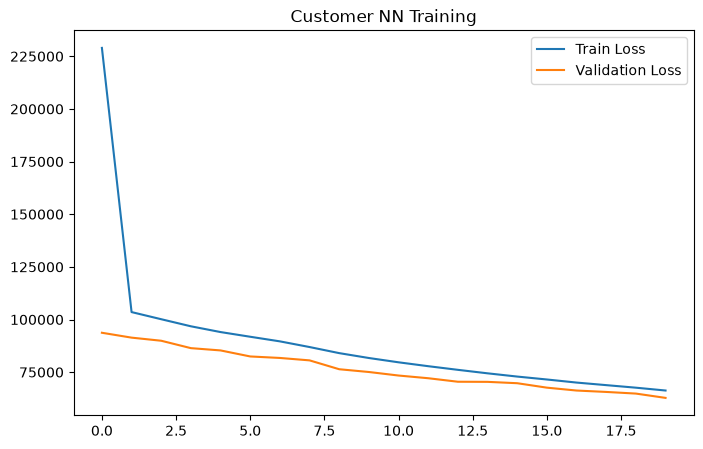

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title(
    "Customer NN Training"
)

plt.show()

In [13]:
cust_nn_preds = customer_nn.predict(
    X_valid_scaled
).flatten()

1832/1832 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

nn_mae = mean_absolute_error(
    y_valid_cust,
    cust_nn_preds
)

nn_rmse = np.sqrt(
    mean_squared_error(
        y_valid_cust,
        cust_nn_preds
    )
)

nn_r2 = r2_score(
    y_valid_cust,
    cust_nn_preds
)

print("Customer NN Results")
print("-"*30)
print(f"MAE  : {nn_mae:.2f}")
print(f"RMSE : {nn_rmse:.2f}")
print(f"R²   : {nn_r2:.4f}")

Customer NN Results
------------------------------
MAE  : 175.14
RMSE : 250.57
R²   : 0.5909


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

In [16]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [17]:
customer_nn_v2 = Sequential([

    Dense(128, activation="relu", input_shape=(29,)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),
    BatchNormalization(),

    Dense(16, activation="relu"),

    Dense(1)
])

c:\Users\Vedant\anaconda3\envs\demand-intel\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
customer_nn_v2.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

In [19]:
history_v2 = customer_nn_v2.fit(
    X_train_scaled,
    y_train_cust,

    validation_data=(
        X_valid_scaled,
        y_valid_cust
    ),

    epochs=50,
    batch_size=1024,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
743/743 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - loss: 557.7411 - mae: 558.2410 - val_loss: 240.3349 - val_mae: 240.8341
Epoch 2/50
743/743 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 213.7106 - mae: 214.2100 - val_loss: 197.3083 - val_mae: 197.8078
Epoch 3/50
743/743 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 205.1100 - mae: 205.6094 - val_loss: 190.1519 - val_mae: 190.6511
Epoch 4/50
743/743 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 200.7460 - mae: 201.2454 - val_loss: 184.1727 - val_mae: 184.6719
Epoch 5/50
743/743 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 196.0890 - mae: 196.5883 - val_loss: 177.4033 - val_mae: 177.9025
Epoch 6/50
743/743 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 192.4528 - mae: 192.9522 - val_loss: 174.9205 - val_mae: 175.4198
Epoch 7/50
743/743 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 189.1543 - mae: 189.6535 - val_loss: 174.4381 - val_mae: 174.9374
Epoch 8/50
743/743 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 186.5383 - mae: 187.0376 - val_loss: 167.788

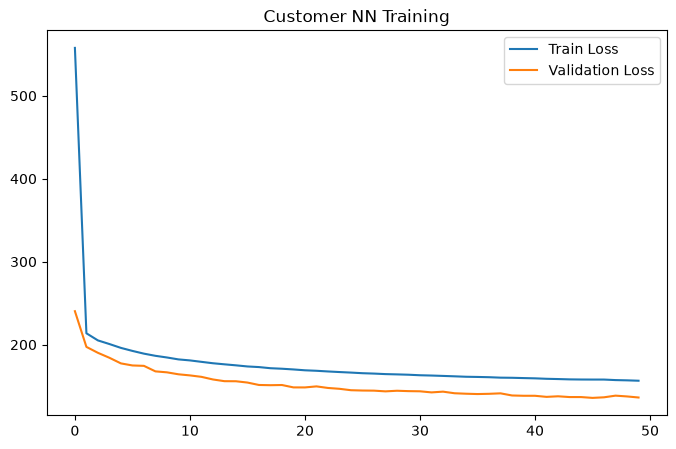

In [20]:


plt.figure(figsize=(8,5))

plt.plot(
    history_v2.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_v2.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title(
    "Customer NN Training"
)

plt.show()

In [21]:
cust_preds_v2 = customer_nn_v2.predict(
    X_valid_scaled
).flatten()

nn_mae_v2 = mean_absolute_error(
    y_valid_cust,
    cust_preds_v2
)

nn_rmse_v2 = np.sqrt(
    mean_squared_error(
        y_valid_cust,
        cust_preds_v2
    )
)

nn_r2_v2 = r2_score(
    y_valid_cust,
    cust_preds_v2
)

print("Customer NN V2 Results")
print("-"*35)
print(f"MAE  : {nn_mae_v2:.2f}")
print(f"RMSE : {nn_rmse_v2:.2f}")
print(f"R²   : {nn_r2_v2:.4f}")

1832/1832 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Customer NN V2 Results
-----------------------------------
MAE  : 136.32
RMSE : 213.99
R²   : 0.7016


### Objective

Train a neural network to forecast sales using the complete engineered feature set and compare its performance against the XGBoost sales forecasting model.

### Feature Strategy

Unlike the customer forecasting model, sales-based lag and rolling statistics are retained because they are available at prediction time and provide valuable information about historical demand patterns.

### Benchmark

The model will be evaluated against the best-performing machine learning model:

- RMSE: 816.03
- R²: 0.9539

### Goal

Determine whether neural networks can effectively leverage engineered sales history features for retail sales forecasting.

In [22]:
sales_drop_cols = [
    "Sales",
    "Date",
    "Open",
    "Customers"
]

X_train_sales = train_open.drop(
    columns=sales_drop_cols
)

X_valid_sales = valid_open.drop(
    columns=sales_drop_cols
)

y_train_sales = train_open["Sales"]
y_valid_sales = valid_open["Sales"]

print(X_train_sales.shape)
print(X_valid_sales.shape)

(760234, 38)
(58611, 38)


In [23]:
from sklearn.preprocessing import StandardScaler

sales_scaler = StandardScaler()

X_train_sales_scaled = sales_scaler.fit_transform(
    X_train_sales
)

X_valid_sales_scaled = sales_scaler.transform(
    X_valid_sales
)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)

sales_nn = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(38,)
    ),
    BatchNormalization(),
    Dropout(0.2),

    Dense(
        64,
        activation="relu"
    ),
    BatchNormalization(),
    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),
    BatchNormalization(),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

c:\Users\Vedant\anaconda3\envs\demand-intel\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
sales_nn.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(),
    metrics=["mae"]
)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [27]:
history_sales = sales_nn.fit(
    X_train_sales_scaled,
    y_train_sales,

    validation_data=(
        X_valid_sales_scaled,
        y_valid_sales
    ),

    epochs=50,
    batch_size=512,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 5222.3350 - mae: 5222.8350 - val_loss: 1161.7083 - val_mae: 1162.2080
Epoch 2/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 899.2433 - mae: 899.7430 - val_loss: 692.0781 - val_mae: 692.5779
Epoch 3/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 804.6705 - mae: 805.1705 - val_loss: 691.3827 - val_mae: 691.8826
Epoch 4/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 770.6575 - mae: 771.1572 - val_loss: 695.3154 - val_mae: 695.8152
Epoch 5/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 747.2958 - mae: 747.7955 - val_loss: 684.2292 - val_mae: 684.7289
Epoch 6/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 720.5372 - mae: 721.0371 - val_loss: 659.2201 - val_mae: 659.7198
Epoch 7/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 697.5315 - mae: 698.0312 - val_loss: 636.3898 - val_mae: 636.8896
Epoch 8/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 678.6573 - mae: 679.1572 - va

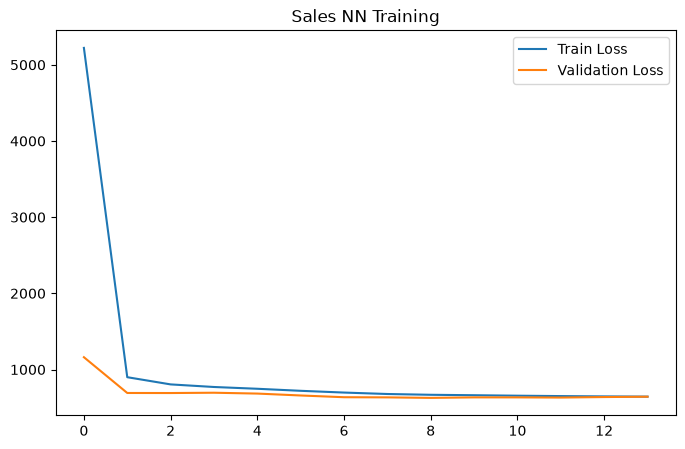

In [28]:


plt.figure(figsize=(8,5))

plt.plot(
    history_sales.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_sales.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title(
    "Sales NN Training"
)

plt.show()

In [29]:
sales_preds_nn = sales_nn.predict(
    X_valid_sales_scaled
).flatten()

sales_mae_nn = mean_absolute_error(
    y_valid_sales,
    sales_preds_nn
)

sales_rmse_nn = np.sqrt(
    mean_squared_error(
        y_valid_sales,
        sales_preds_nn
    )
)

sales_r2_nn = r2_score(
    y_valid_sales,
    sales_preds_nn
)

print("Sales NN Results")
print("-"*30)
print(f"MAE  : {sales_mae_nn:.2f}")
print(f"RMSE : {sales_rmse_nn:.2f}")
print(f"R²   : {sales_r2_nn:.4f}")

1832/1832 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Sales NN Results
------------------------------
MAE  : 628.12
RMSE : 911.58
R²   : 0.9141


## Multi task Neural Network Architecture

In [11]:
multi_drop_cols = [
    "Sales",
    "Customers",
    "Date",
    "Open"
]

In [12]:
X_train_multi = train_open.drop(
    columns=multi_drop_cols
)

X_valid_multi = valid_open.drop(
    columns=multi_drop_cols
)

print(X_train_multi.shape)
print(X_valid_multi.shape)

(760234, 38)
(58611, 38)


In [13]:
# Customer targets
y_train_customers = train_open["Customers"]
y_valid_customers = valid_open["Customers"]

# Sales targets
y_train_sales = train_open["Sales"]
y_valid_sales = valid_open["Sales"]

print(y_train_customers.shape)
print(y_valid_customers.shape)

print(y_train_sales.shape)
print(y_valid_sales.shape)

(760234,)
(58611,)
(760234,)
(58611,)


In [14]:
from sklearn.preprocessing import StandardScaler

multi_scaler = StandardScaler()

X_train_multi_scaled = multi_scaler.fit_transform(
    X_train_multi
)

X_valid_multi_scaled = multi_scaler.transform(
    X_valid_multi
)

In [15]:
from tensorflow.keras.layers import (
    Input,
    Dense,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.models import Model

In [45]:
inputs = Input(shape=(38,))

x = Dense(256, activation="relu")(inputs)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

shared = Dense(32, activation="relu")(x)

customer_output = Dense(
    1,
    name="customer_output"
)(shared)

sales_output = Dense(
    1,
    name="sales_output"
)(shared)

multi_task_model = Model(
    inputs=inputs,
    outputs=[
        customer_output,
        sales_output
    ]
)

In [116]:
#Shared architecture for trial purposes
from tensorflow.keras.layers import (
    Input,
    Dense,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.models import Model

inputs = Input(shape=(38,))

# ======================
# Shared Layers
# ======================

x = Dense(256, activation="relu")(inputs)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

shared = Dense(64, activation="relu")(x)

# ======================
# Customer Branch
# ======================

cust = Dense(32, activation="relu")(shared)
cust = BatchNormalization()(cust)

cust = Dense(16, activation="relu")(cust)

customer_output = Dense(
    1,
    name="customer_output"
)(cust)

# ======================
# Sales Branch
# ======================

sales = Dense(32, activation="relu")(shared)
sales = BatchNormalization()(sales)

sales = Dense(16, activation="relu")(sales)

sales_output = Dense(
    1,
    name="sales_output"
)(sales)

# ======================
# Final Model
# ======================

multi_task_model = Model(
    inputs=inputs,
    outputs=[
        customer_output,
        sales_output
    ]
)

multi_task_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 256)       │      9,984 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_31[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 128)       │     32,896 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_32[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 64)        │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_33[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 64)        │      4,160 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 32)        │      2,080 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 32)        │      2,080 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_35[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_37[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 16)        │        528 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 16)        │        528 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ customer_output     │ (None, 1)         │         17 │ dense_36[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sales_output        │ (None, 1)         │         17 │ dense_38[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 62,594 (244.51 KB)

 Trainable params: 61,570 (240.51 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [117]:
from tensorflow.keras import optimizers

multi_task_model.compile(
    # Pass the optimizer object with your desired learning rate here
    optimizer=optimizers.Adam(learning_rate=0.0005),

    loss={
        "customer_output": "mse",
        "sales_output": "mse"
    },

    loss_weights={
    "customer_output": 1.8,
    "sales_output": 1.0
    },

    metrics={
        "customer_output": ["mae"],
        "sales_output": ["mae"]
    }
)

In [118]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=18,
    restore_best_weights=True
)

In [119]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [120]:
history_multi = multi_task_model.fit(

    X_train_multi_scaled,

    {
        "customer_output": y_train_customers,
        "sales_output": y_train_sales
    },

    validation_data=(

        X_valid_multi_scaled,

        {
            "customer_output": y_valid_customers,
            "sales_output": y_valid_sales
        }
    ),

    epochs=50,
    batch_size=512,

    callbacks=[early_stop, reduce_lr],

    verbose=1
)

Epoch 1/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - customer_output_loss: 465842.3438 - customer_output_mae: 584.9227 - loss: 55749560.0000 - sales_output_loss: 54910000.0000 - sales_output_mae: 6774.8032 - val_customer_output_loss: 86193.1797 - val_customer_output_mae: 224.0390 - val_loss: 49714048.0000 - val_sales_output_loss: 49919064.0000 - val_sales_output_mae: 6492.8271 - learning_rate: 5.0000e-04
Epoch 2/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - customer_output_loss: 49017.3047 - customer_output_mae: 160.9704 - loss: 32693294.0000 - sales_output_loss: 32603482.0000 - sales_output_mae: 5197.7251 - val_customer_output_loss: 29141.8477 - val_customer_output_mae: 118.0549 - val_loss: 15483828.0000 - val_sales_output_loss: 15530709.0000 - val_sales_output_mae: 3596.4944 - learning_rate: 5.0000e-04
Epoch 3/50
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - customer_output_loss: 33559.6641 - customer_output_mae: 130.1778 - loss: 7315581.5000 - sales_output_loss: 7254547.00

In [121]:
cust_preds_multi, sales_preds_multi = (
    multi_task_model.predict(
        X_valid_multi_scaled
    )
)

1832/1832 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [122]:
cust_preds_multi = cust_preds_multi.flatten()
sales_preds_multi = sales_preds_multi.flatten()

In [123]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [124]:
cust_r2_multi = r2_score(
    y_valid_customers,
    cust_preds_multi
)

cust_rmse_multi = np.sqrt(
    mean_squared_error(
        y_valid_customers,
        cust_preds_multi
    )
)

print("cust_r2_multi:", cust_r2_multi)
print("cust_rmse_multi:", cust_rmse_multi)

cust_r2_multi: 0.8377070426940918
cust_rmse_multi: 157.8177288737707


In [125]:
sales_r2_multi = r2_score(
    y_valid_sales,
    sales_preds_multi
)

sales_rmse_multi = np.sqrt(
    mean_squared_error(
        y_valid_sales,
        sales_preds_multi
    )
)

print("sales_r2_multi:", sales_r2_multi)
print("sales_rmse_multi:", sales_rmse_multi)

sales_r2_multi: 0.8985902667045593
sales_rmse_multi: 990.7412628935973


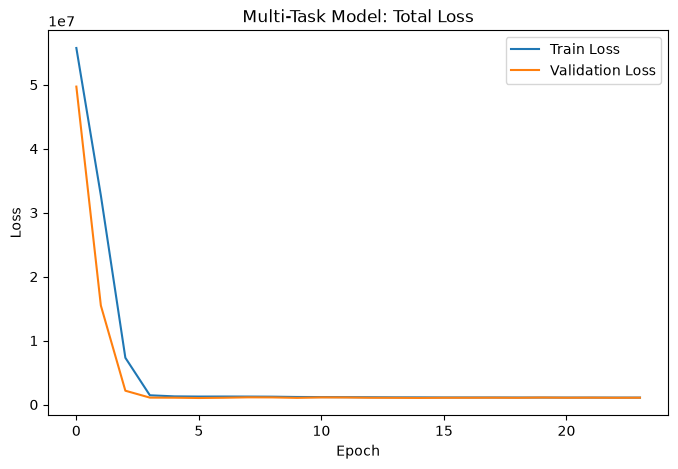

In [126]:
#Total loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_multi.history['loss'], label='Train Loss')
plt.plot(history_multi.history['val_loss'], label='Validation Loss')

plt.title('Multi-Task Model: Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

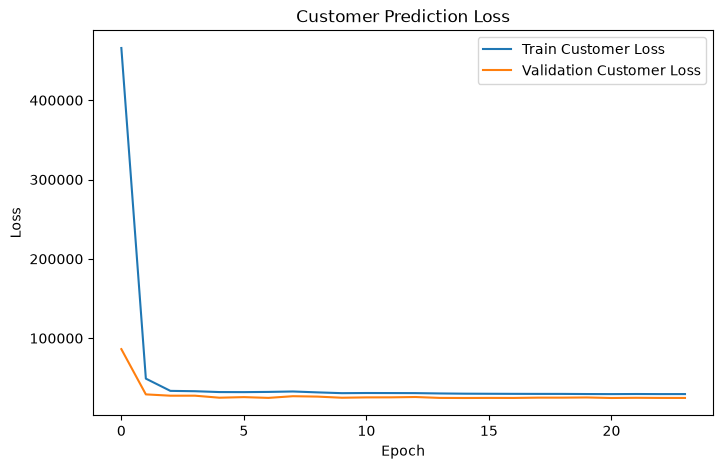

In [127]:
#Customer loss
plt.figure(figsize=(8,5))

plt.plot(
    history_multi.history['customer_output_loss'],
    label='Train Customer Loss'
)

plt.plot(
    history_multi.history['val_customer_output_loss'],
    label='Validation Customer Loss'
)

plt.title('Customer Prediction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

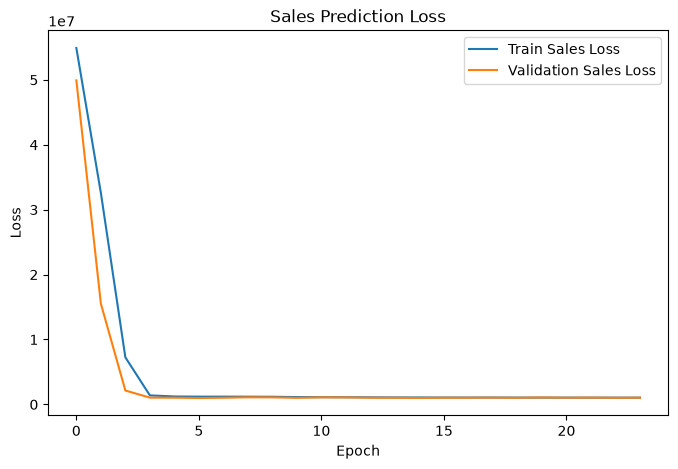

In [128]:
#Sales loss
plt.figure(figsize=(8,5))

plt.plot(
    history_multi.history['sales_output_loss'],
    label='Train Sales Loss'
)

plt.plot(
    history_multi.history['val_sales_output_loss'],
    label='Validation Sales Loss'
)

plt.title('Sales Prediction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

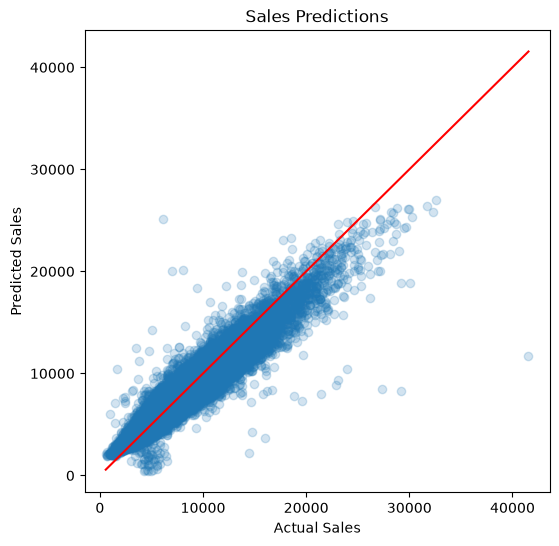

In [129]:
#Actual vs Predicted Sales Scatter Plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_valid_sales,
    sales_preds_multi,
    alpha=0.2
)

plt.plot(
    [y_valid_sales.min(), y_valid_sales.max()],
    [y_valid_sales.min(), y_valid_sales.max()],
    'r'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Sales Predictions")

plt.show()

## Key Findings

1. XGBoost achieved the best overall forecasting performance, reaching an R² of 0.9539 and RMSE of 816.03 on open-store sales forecasting.

2. Neural networks were competitive but consistently underperformed tree-based ensemble methods on structured retail data.

3. Multi-task learning significantly improved customer forecasting performance, increasing customer R² from 0.684 to 0.847.

4. Sales forecasting benefited strongly from historical lag and rolling features, while customer forecasting benefited more from shared representations learned through multi-task learning.

5. For this dataset, tree-based methods remain the preferred production solution, while deep learning architectures provide valuable experimentation and insights into demand relationships.
